In this notebook, the performance measures are compared between male and female participants. The goal is to explore and detect if any sex differences might exist in the motor performance of the chord tasks. Substantial differences are not expected in this task.

**Results Summary**:
1. In experiment 1 (all 242 chords), no significant difference in our dataset with 7 Male, 7 Female was observed in any of the performance measure. Overall  average success rate was similar. The MD differences are essentially non-existent. The RT and ET differences might be there - Male was a bit faster. Power anlaysis with 80% power suggest  n~25 per sex group for RT and n~40 per sex group to observe differences.

2. In experiment 2 participants trained on 4 chords 29212.92122.91211.22911 and test 4 other chords 21291.12129.12291.19111 (9 is still, 1 is extension, 2 is flexion). Here we had 5 female and 10 male participants. The MD is quite different between the groups. For the trained chords the difference becomes significant. For the untrained chords the difference is not significant. However, power anlaysis with 80% power suggests n=~16 per sex group to observe a difference. The RT and ET on the other hand generally do not show any difference.

In [80]:
import pandas as pd
from utils.config import *
import importlib
import efc2_paper as paper
importlib.reload(paper)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%config InlineBackend.figure_format = 'retina'


participant sex info:

In [31]:
# all 242 chords experiment:
EFC1_sex = ['M','M','F','M','M','F','F','F','M','M','F','M','F','F'] # 7 male, 7 female

# learning chord experiment:
EFC2_sex = ['M','M','M','M','F','M','M','F','F','F','M','M','F','M'] # 9 male, 5 female

# EMG chord experiment:
EFC3_sex = ['M','M','M','M','F','M','F','F','F','F'] # 5 male, 5 female

mycolor = ['#2E4057','#D7263D'] # male, female

## Exp1 success rate

Text(0, 0.5, 'success rate')

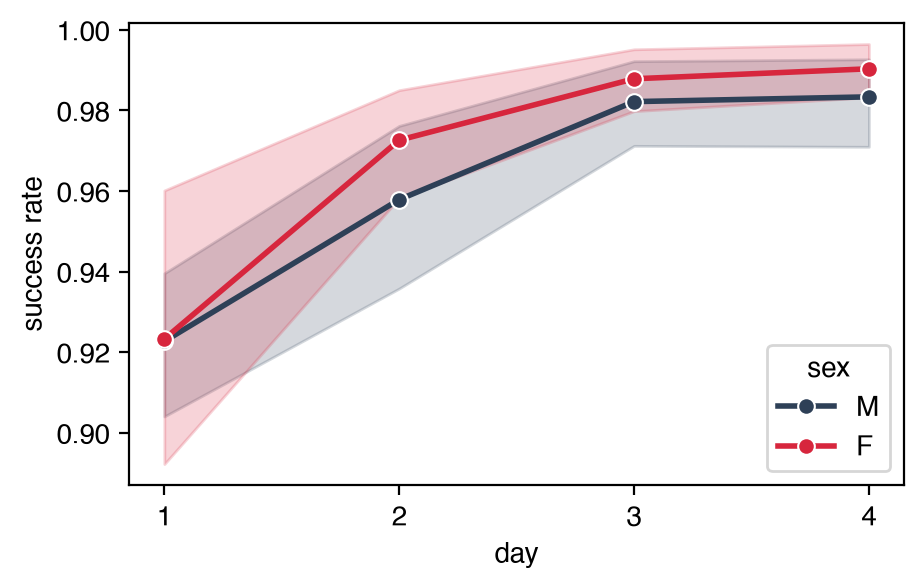

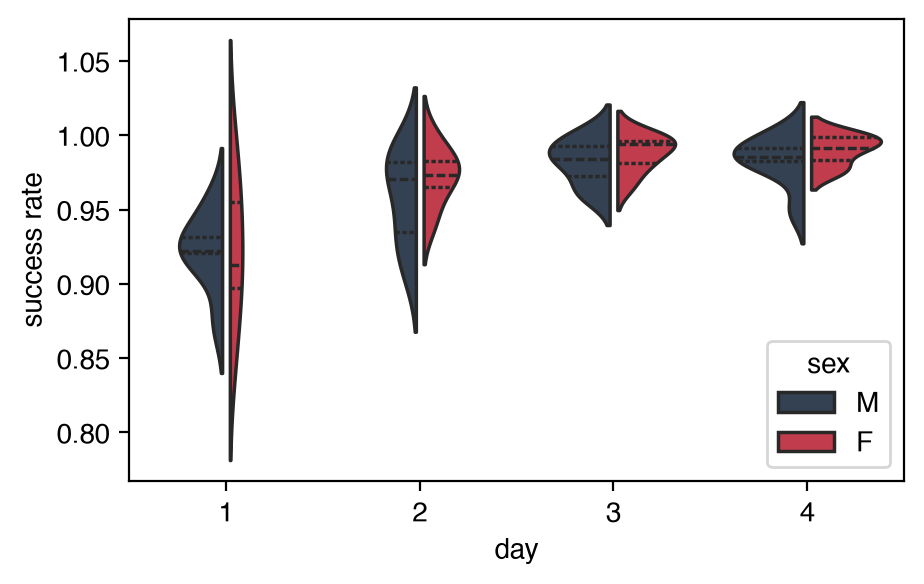

In [81]:
d = pd.read_table(os.path.join(os.getcwd(),'data','efc1_chord.tsv'), sep='\t')

# map sex onto each sn (element-wise with EFC1_sex)
sn_to_sex = dict(zip(d.sn.unique(), EFC1_sex))
d.insert(d.columns.get_loc('sn') + 1, 'sex', d.sn.map(sn_to_sex))

# double check the sex info:
# print(d[['sn', 'sex']].drop_duplicates().to_string(index=False)) 

# success rate of chords:
# group by sex and sess:
d_avg = d.groupby(['sex','sess', 'sn']).agg({'accuracy':'mean'}).reset_index()

# line plot sns:
fig, ax = plt.subplots(figsize=(5, 3))
sns.lineplot(data=d_avg, x='sess', y='accuracy', hue='sex', palette=mycolor, hue_order=['M','F'],
            marker='o', lw=2)
ax.set_xticks([1,2,3,4])
ax.set_xlabel('day')
ax.set_ylabel('success rate')

# male and female histograms:
fig, ax = plt.subplots(figsize=(5, 3))
sns.violinplot(data=d_avg, x='sess', y='accuracy', hue='sex', split=True, gap=.1, inner="quart", 
                palette=mycolor, hue_order=['M','F'])
ax.set_xlabel('day')
ax.set_ylabel('success rate')


## Exp1 performance

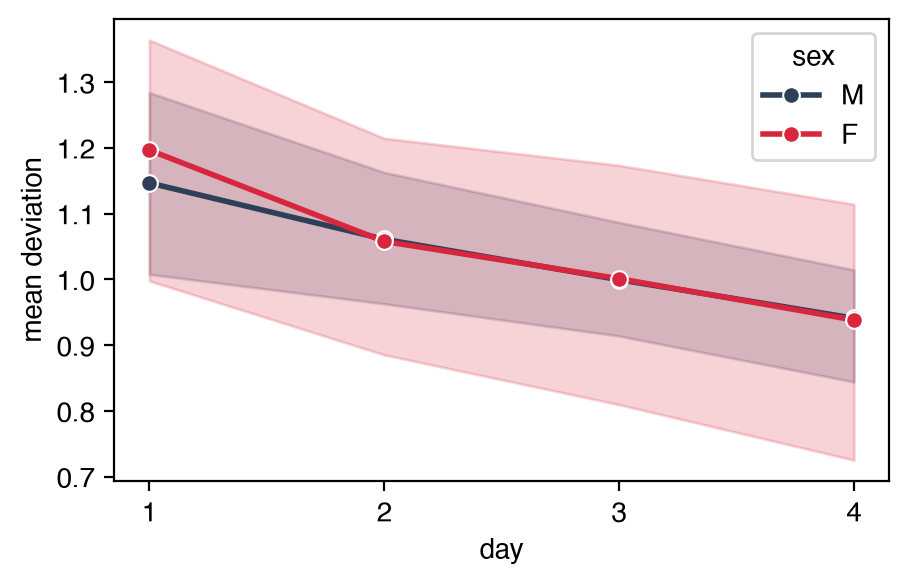

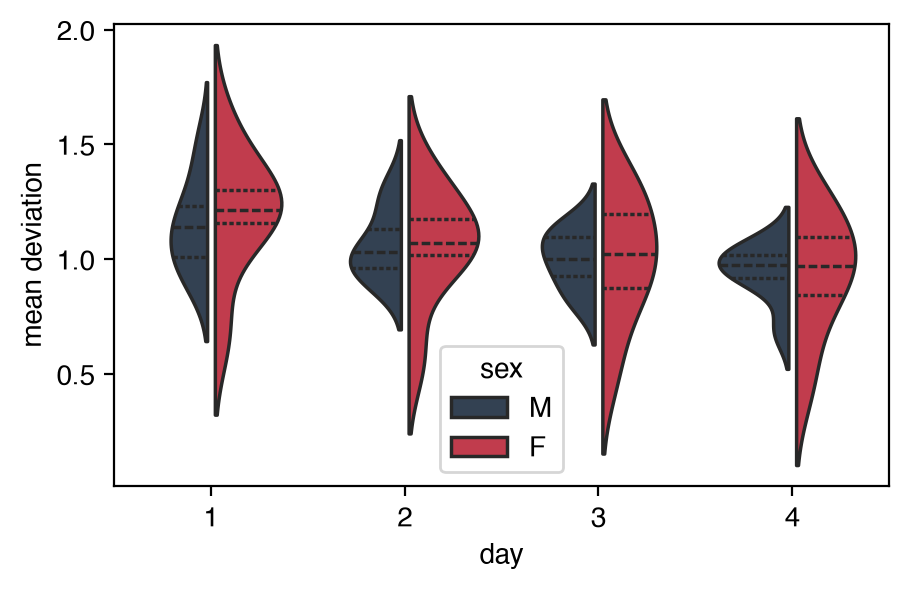

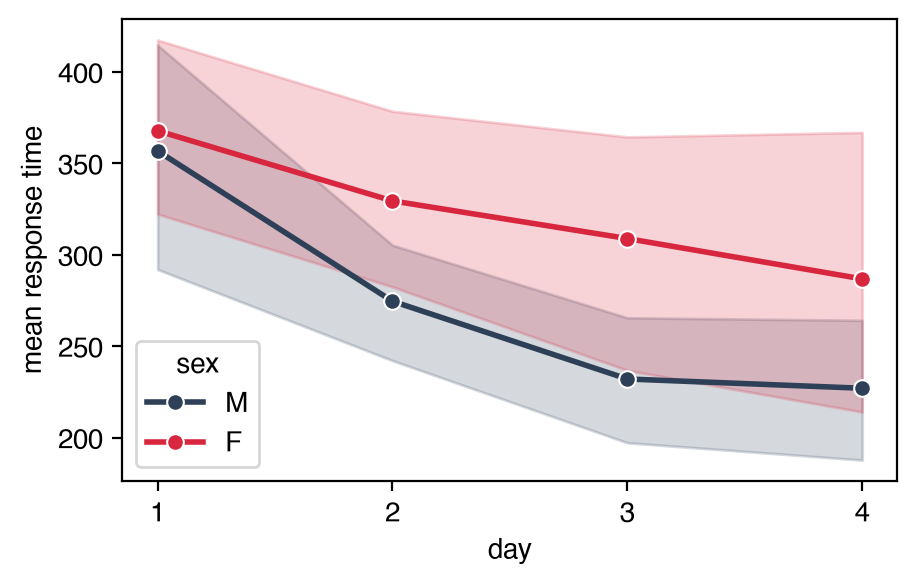

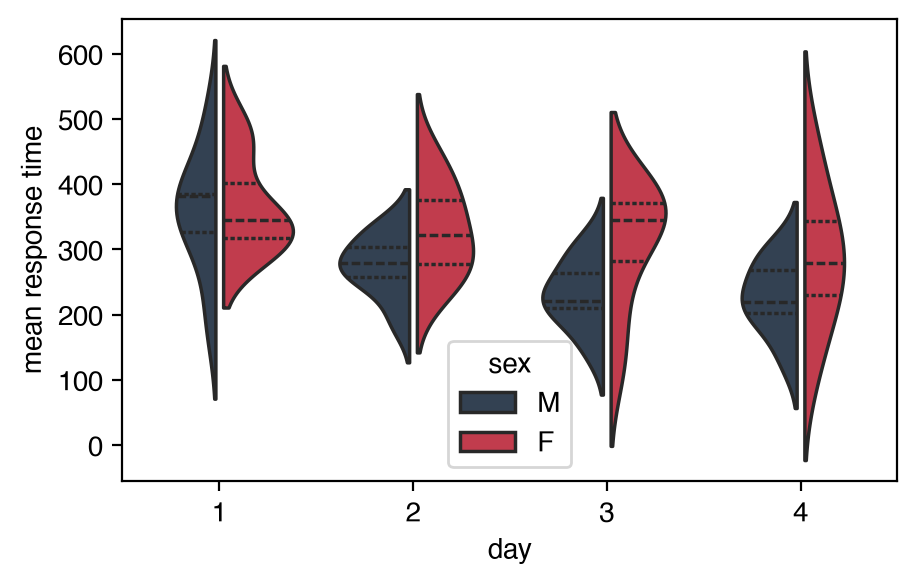

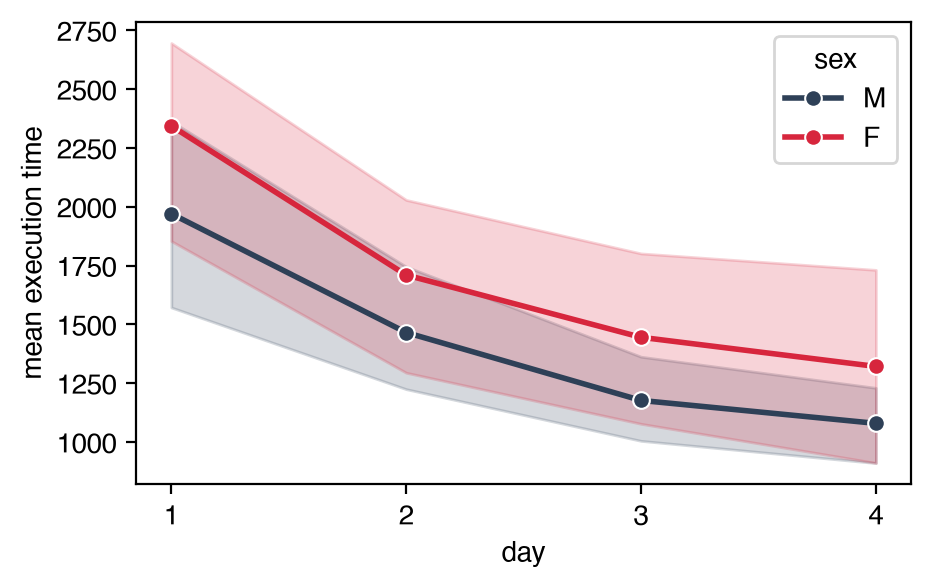

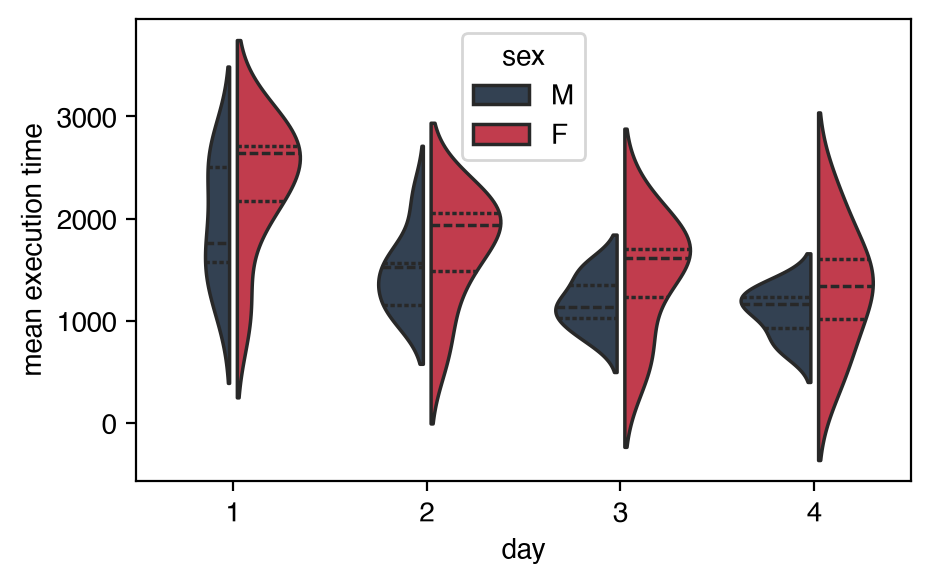

In [82]:
d = pd.read_table(os.path.join(os.getcwd(),'data','efc1_chord.tsv'), sep='\t')
for col in ['MD', 'RT', 'ET', 'MT']:
    d[col] = pd.to_numeric(d[col], errors='coerce')

# map sex onto each sn (element-wise with EFC1_sex)
sn_to_sex = dict(zip(d.sn.unique(), EFC1_sex))
d.insert(d.columns.get_loc('sn') + 1, 'sex', d.sn.map(sn_to_sex))

# group by sex and sess:
d_avg = d.groupby(['sex','sess', 'sn']).agg({'MD':'mean', 'RT':'mean', 'ET':'mean'}).reset_index()

# line plot sns:
ylabels = ['mean deviation', 'mean response time', 'mean execution time']
for col, ylabel in zip(['MD', 'RT', 'ET'], ylabels):
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.lineplot(data=d_avg, x='sess', y=col, hue='sex', palette=mycolor, hue_order=['M','F'],
                marker='o', lw=2)
    ax.set_xticks([1,2,3,4])
    ax.set_xlabel('day')
    ax.set_ylabel(ylabel)

    # male and female histograms:
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.violinplot(data=d_avg, x='sess', y=col, hue='sex', split=True, gap=.1, inner="quart", 
                    palette=mycolor, hue_order=['M','F'])
    ax.set_xlabel('day')
    ax.set_ylabel(ylabel)



### Stats: male vs female (MD, RT, ET)

Subject-level means averaged across days, then compared between sexes.

In [63]:
from scipy import stats
from statsmodels.stats.power import TTestIndPower

# subject means averaged across days (sess)
d_subj = d_avg.groupby(['sex', 'sn']).agg({'MD': 'mean', 'RT': 'mean', 'ET': 'mean'}).reset_index()

print('n male:', (d_subj.sex == 'M').sum(), ' | n female:', (d_subj.sex == 'F').sum())
print('=' * 70)

power_analysis = TTestIndPower()

for col in ['MD', 'RT', 'ET']:
    male = d_subj.loc[d_subj.sex == 'M', col].values
    female = d_subj.loc[d_subj.sex == 'F', col].values

    mean_m, mean_f = male.mean(), female.mean()
    sd_m, sd_f = male.std(ddof=1), female.std(ddof=1)
    n_m, n_f = len(male), len(female)

    # mean difference (M - F) and SE of the mean difference
    mean_diff = mean_m - mean_f
    se_diff = np.sqrt(sd_m**2 / n_m + sd_f**2 / n_f)

    # Welch's independent-samples t-test
    t_stat, p_val = stats.ttest_ind(male, female, equal_var=False)
    df_welch = se_diff**4 / ((sd_m**2 / n_m)**2 / (n_m - 1) + (sd_f**2 / n_f)**2 / (n_f - 1))

    # Cohen's d (pooled SD)
    s_pooled = np.sqrt(((n_m - 1) * sd_m**2 + (n_f - 1) * sd_f**2) / (n_m + n_f - 2))
    cohens_d = mean_diff / s_pooled

    # sample size per group for 80% power (two-sided, alpha=0.05)
    if abs(cohens_d) > 1e-6:
        n_needed = power_analysis.solve_power(
            effect_size=abs(cohens_d), power=0.8, alpha=0.05, alternative='two-sided'
        )
        n_needed_str = f'{np.ceil(n_needed):.0f} per group ({np.ceil(n_needed)*2:.0f} total)'
    else:
        n_needed_str = 'effect ~0 (essentially infinite n)'

    print(f'\n{col}')
    print('-' * 40)
    print(f'  Male:   mean = {mean_m:.4f}, SD = {sd_m:.4f}, n = {n_m}')
    print(f'  Female: mean = {mean_f:.4f}, SD = {sd_f:.4f}, n = {n_f}')
    print(f'  Mean difference (M - F): {mean_diff:.4f}')
    print(f'  SE of mean difference:   {se_diff:.4f}')
    print(f'  Welch t-test: t({df_welch:.1f}) = {t_stat:.4f}, p = {p_val:.4f}')
    print(f"  Cohen's d: {cohens_d:.4f}")
    print(f'  Power analysis (80% power, α=0.05, two-sided):')
    print(f'    n needed to detect this effect size: {n_needed_str}')

print('\n' + '=' * 70)
print('Note: power analysis uses the observed Cohen\'s d from this sample.')
print('MD shows really no sex difference; RT/ET may show some effects')
print('that are not significant at n=7 per group.')


n male: 7  | n female: 7

MD
----------------------------------------
  Male:   mean = 1.0372, SD = 0.1260, n = 7
  Female: mean = 1.0486, SD = 0.2534, n = 7
  Mean difference (M - F): -0.0114
  SE of mean difference:   0.1070
  Welch t-test: t(8.8) = -0.1063, p = 0.9177
  Cohen's d: -0.0568
  Power analysis (80% power, α=0.05, two-sided):
    n needed to detect this effect size: 4865 per group (9730 total)

RT
----------------------------------------
  Male:   mean = 272.6107, SD = 52.5635, n = 7
  Female: mean = 323.2196, SD = 66.8094, n = 7
  Mean difference (M - F): -50.6089
  SE of mean difference:   32.1301
  Welch t-test: t(11.4) = -1.5751, p = 0.1426
  Cohen's d: -0.8419
  Power analysis (80% power, α=0.05, two-sided):
    n needed to detect this effect size: 24 per group (48 total)

ET
----------------------------------------
  Male:   mean = 1422.9111, SD = 343.9968, n = 7
  Female: mean = 1704.9276, SD = 547.6620, n = 7
  Mean difference (M - F): -282.0165
  SE of mean diffe

## Exp2 performance

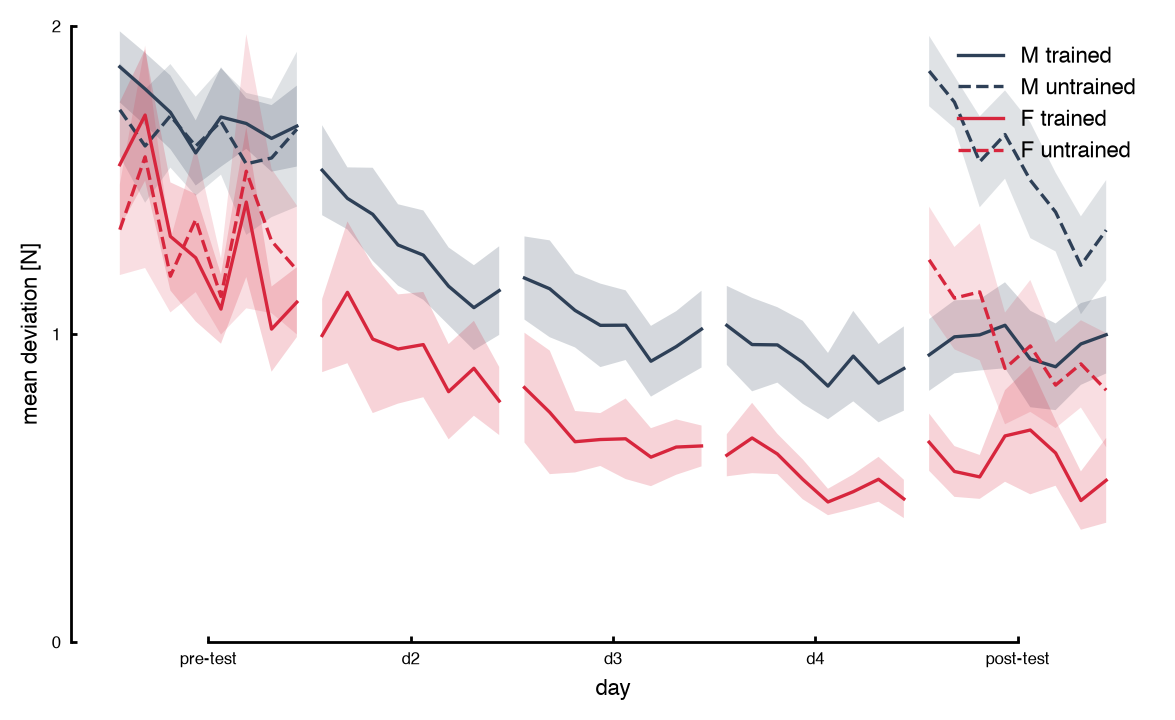

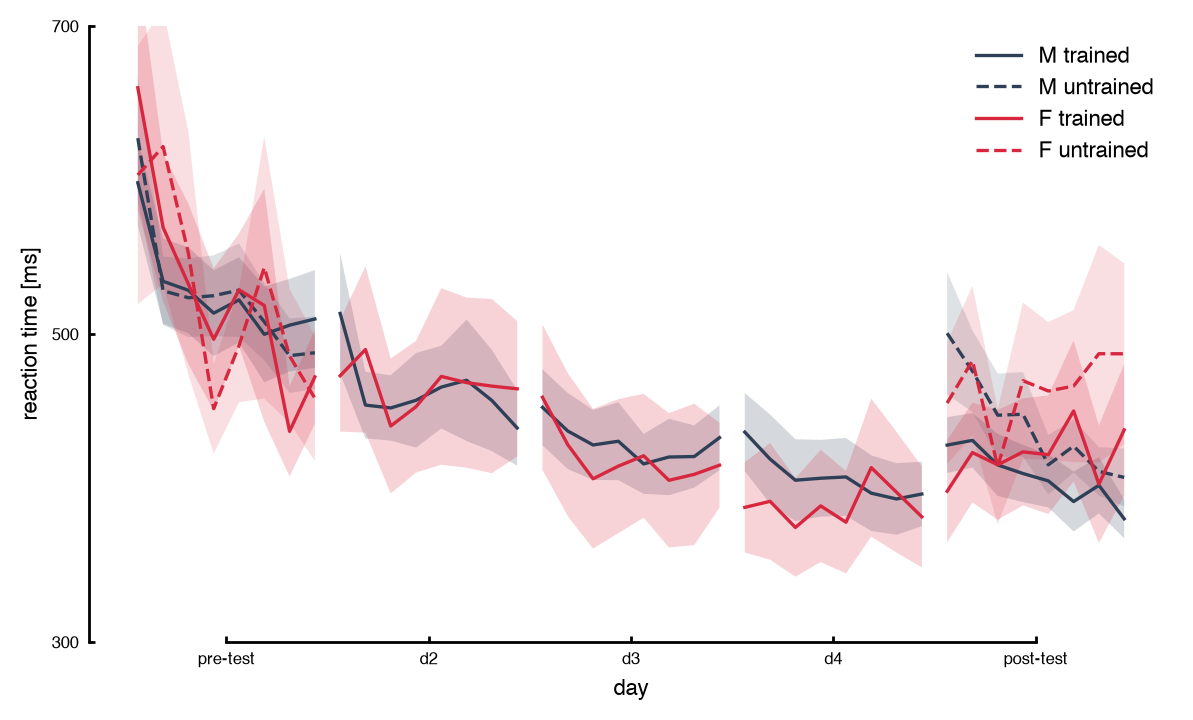

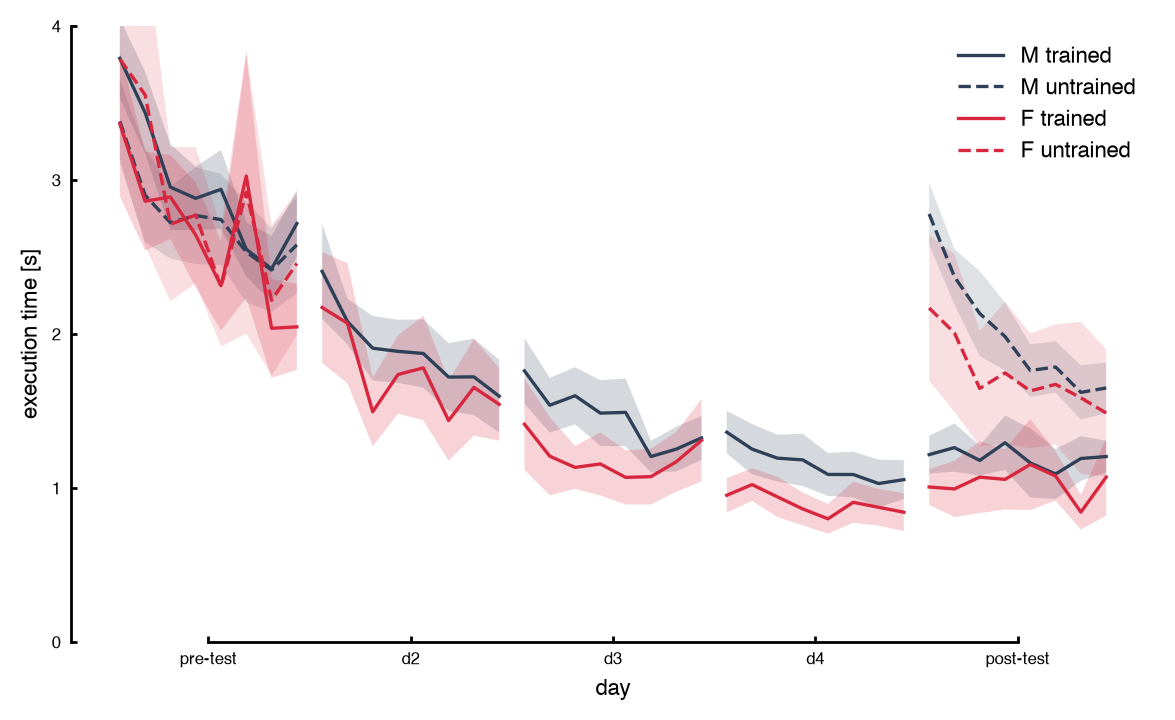

In [ ]:
from utils.figure_style import my_paper

df = pd.read_csv(os.path.join(os.getcwd(), 'data', 'efc2_all.csv'))
# make summary dataframe:
df.replace(-1, np.nan, inplace=True)
df = df.groupby(['day', 'sn', 'trained', 'BN'])[['is_test', 'group', 'RT', 'ET', 'MD']].mean().reset_index()
num_blocks = df['BN'].unique().shape[0]

# map sex onto each sn (element-wise with EFC2_sex)
sn_to_sex = dict(zip(df.sn.unique(), EFC2_sex))
df.insert(df.columns.get_loc('sn') + 1, 'sex', df.sn.map(sn_to_sex))

df_avg = df.groupby(['day', 'trained', 'BN', 'sex']).agg(
    MD_mean=('MD', 'mean'),
    MD_sem=('MD', 'sem'),
    RT_mean=('RT', 'mean'),
    RT_sem=('RT', 'sem'),
    ET_mean=('ET', 'mean'),
    ET_sem=('ET', 'sem'),
    len_avg=('MD', 'count')
).reset_index()
df_avg['adjusted_BN'] = (df_avg['day'] - 1) * num_blocks + df_avg['BN']


def plot_sex_learning(df_avg, measure='MD', fig_size=(7, 4), show_legend=True):
    '''Learning curves by sex. Trained=solid, untrained=dashed (days 1 & 5).'''
    sex_colors = {'M': mycolor[0], 'F': mycolor[1]}
    fig, ax = plt.subplots(figsize=fig_size)

    for sex in ['M', 'F']:
        color = sex_colors[sex]

        # Trained (solid) — all days
        trained = df_avg[(df_avg['sex'] == sex) & (df_avg['trained'] == 1)]
        for day in sorted(trained['day'].unique()):
            day_data = trained[trained['day'] == day].sort_values('adjusted_BN')
            ax.plot(day_data['adjusted_BN'], day_data[f'{measure}_mean'],
                    color=color, linestyle='-', linewidth=my_paper['line_width'],
                    label=f'{sex} trained' if day == trained['day'].min() else None)
            ax.fill_between(
                day_data['adjusted_BN'],
                day_data[f'{measure}_mean'] - day_data[f'{measure}_sem'],
                day_data[f'{measure}_mean'] + day_data[f'{measure}_sem'],
                color=color, alpha=0.2, edgecolor='none')

        # Untrained (dashed) — days 1 and 5 only
        untrained = df_avg[(df_avg['sex'] == sex) & (df_avg['trained'] == 0)]
        for day in sorted(untrained['day'].unique()):
            day_data = untrained[untrained['day'] == day].sort_values('adjusted_BN')
            ax.plot(day_data['adjusted_BN'], day_data[f'{measure}_mean'],
                    color=color, linestyle='--', linewidth=my_paper['line_width'],
                    label=f'{sex} untrained' if day == untrained['day'].min() else None)
            ax.fill_between(
                day_data['adjusted_BN'],
                day_data[f'{measure}_mean'] - day_data[f'{measure}_sem'],
                day_data[f'{measure}_mean'] + day_data[f'{measure}_sem'],
                color=color, alpha=0.15, edgecolor='none')

    if measure == 'MD':
        ax.set_ylim([0, 2])
        ax.set_yticks([0, 1, 2])
        ax.set_ylabel('mean deviation [N]', fontsize=my_paper['label_fontsize'])
    elif measure == 'RT':
        ax.set_ylim([300, 700])
        ax.set_yticks([300, 500, 700])
        ax.set_ylabel('reaction time [ms]', fontsize=my_paper['label_fontsize'])
    elif measure == 'ET':
        ax.set_ylim([0, 4000])
        ax.set_yticks([0, 1000, 2000, 3000, 4000], labels=['0', '1', '2', '3', '4'])
        ax.set_ylabel('execution time [s]', fontsize=my_paper['label_fontsize'])

    ax.set_xticks([4.5, 12.5, 20.5, 28.5, 36.5], labels=['pre-test', 'd2', 'd3', 'd4', 'post-test'])
    ax.set_xlabel('day', fontsize=my_paper['label_fontsize'])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['left'].set_bounds(ax.get_ylim()[0], ax.get_ylim()[-1])
    ax.spines['bottom'].set_bounds(ax.get_xticks()[0], ax.get_xticks()[-1])
    ax.tick_params(axis='x', direction='in', length=2, width=my_paper['axis_width'])
    ax.tick_params(axis='y', direction='in', length=2, width=my_paper['axis_width'])
    ax.tick_params(axis='both', labelsize=my_paper['tick_fontsize'])

    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, fontsize=my_paper['leg_fontsize'], frameon=False, loc='upper right')

    plt.show()
    return fig, ax

for measure in ['MD', 'RT', 'ET']:
    plot_sex_learning(df_avg, measure=measure)


### Stats: male vs female (MD, RT, ET) — Exp2

Subject-level means averaged across days, separately for **trained** and **untrained** chords (never mixed). Then compared between sexes within each chord type.


In [ ]:
from scipy import stats
from statsmodels.stats.power import TTestIndPower

# subject means averaged across days, kept separate by trained / untrained
d_subj = df.groupby(['sex', 'sn', 'trained']).agg({'MD': 'mean', 'RT': 'mean', 'ET': 'mean'}).reset_index()

power_analysis = TTestIndPower()

for trained_val, label in [(1, 'TRAINED'), (0, 'UNTRAINED')]:
    sub = d_subj[d_subj.trained == trained_val]

    print('=' * 70)
    print(f'{label} chords — subject means averaged across days')
    print(f'n male: {(sub.sex == "M").sum()}  |  n female: {(sub.sex == "F").sum()}')
    print('=' * 70)

    for col in ['MD', 'RT', 'ET']:
        male = sub.loc[sub.sex == 'M', col].values
        female = sub.loc[sub.sex == 'F', col].values

        mean_m, mean_f = male.mean(), female.mean()
        sd_m, sd_f = male.std(ddof=1), female.std(ddof=1)
        n_m, n_f = len(male), len(female)

        # mean difference (M - F) and SE of the mean difference
        mean_diff = mean_m - mean_f
        se_diff = np.sqrt(sd_m**2 / n_m + sd_f**2 / n_f)

        # Welch's independent-samples t-test
        t_stat, p_val = stats.ttest_ind(male, female, equal_var=False)
        df_welch = se_diff**4 / ((sd_m**2 / n_m)**2 / (n_m - 1) + (sd_f**2 / n_f)**2 / (n_f - 1))

        # Cohen's d (pooled SD)
        s_pooled = np.sqrt(((n_m - 1) * sd_m**2 + (n_f - 1) * sd_f**2) / (n_m + n_f - 2))
        cohens_d = mean_diff / s_pooled

        # sample size per group for 80% power (two-sided, alpha=0.05)
        if abs(cohens_d) > 1e-6:
            n_needed = power_analysis.solve_power(
                effect_size=abs(cohens_d), power=0.8, alpha=0.05, alternative='two-sided'
            )
            n_needed_str = f'{np.ceil(n_needed):.0f} per group ({np.ceil(n_needed)*2:.0f} total)'
        else:
            n_needed_str = 'effect ~0 (essentially infinite n)'

        print(f'\n{col}')
        print('-' * 40)
        print(f'  Male:   mean = {mean_m:.4f}, SD = {sd_m:.4f}, n = {n_m}')
        print(f'  Female: mean = {mean_f:.4f}, SD = {sd_f:.4f}, n = {n_f}')
        print(f'  Mean difference (M - F): {mean_diff:.4f}')
        print(f'  SE of mean difference:   {se_diff:.4f}')
        print(f'  Welch t-test: t({df_welch:.1f}) = {t_stat:.4f}, p = {p_val:.4f}')
        print(f"  Cohen's d: {cohens_d:.4f}")
        print(f'  Power analysis (80% power, α=0.05, two-sided):')
        print(f'    n needed to detect this effect size: {n_needed_str}')

    print()

print('=' * 70)
print('Note: trained and untrained are tested separately (never mixed).')
print('Untrained chords occur on days 1 & 5 only; trained on all days.')
print('Power analysis uses the observed Cohen\'s d from this sample.')
print('n = 9 male, 5 female.')


TRAINED chords — subject means averaged across days
n male: 9  |  n female: 5

MD
----------------------------------------
  Male:   mean = 1.1846, SD = 0.3374, n = 9
  Female: mean = 0.8103, SD = 0.2641, n = 5
  Mean difference (M - F): 0.3743
  SE of mean difference:   0.1631
  Welch t-test: t(10.3) = 2.2950, p = 0.0439
  Cohen's d: 1.1887
  Power analysis (80% power, α=0.05, two-sided):
    n needed to detect this effect size: 13 per group (26 total)

RT
----------------------------------------
  Male:   mean = 446.8936, SD = 58.9944, n = 9
  Female: mean = 444.5146, SD = 82.5730, n = 5
  Mean difference (M - F): 2.3790
  SE of mean difference:   41.8373
  Welch t-test: t(6.3) = 0.0569, p = 0.9564
  Cohen's d: 0.0351
  Power analysis (80% power, α=0.05, two-sided):
    n needed to detect this effect size: 12740 per group (25480 total)

ET
----------------------------------------
  Male:   mean = 1734.8407, SD = 454.1283, n = 9
  Female: mean = 1502.0505, SD = 446.1130, n = 5
  Mean 